1. Loading data...
Mounted at /content/drive
        timestamp_utc  load_actual_mw  load_forecast_mw  temperature_c  \
0 2015-01-01 01:15:00          9025.0           8631.36        1.58075   
1 2015-01-01 01:30:00          8889.0           8569.59        1.53650   
2 2015-01-01 01:45:00          8765.0           8517.49        1.49225   
3 2015-01-01 02:00:00          8639.0           8492.69        1.44800   
4 2015-01-01 02:15:00          8514.0           8482.99        1.39850   

   rad_direct  rad_diffuse  hour  minute  dayofweek  month  ...  lag_60m  \
0         0.0          0.0     1      15          3      1  ...   9524.0   
1         0.0          0.0     1      30          3      1  ...   9407.0   
2         0.0          0.0     1      45          3      1  ...   9271.0   
3         0.0          0.0     2       0          3      1  ...   9148.0   
4         0.0          0.0     2      15          3      1  ...   9025.0   

   temperature_lag_15m  temperature_lag_60m  rad_dire

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,801 (206.25 KB)

 Trainable params: 52,801 (206.25 KB)

 Non-trainable params: 0 (0.00 B)

5. Training Model...
Epoch 1/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 63s 29ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 2/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 78s 27ms/step - loss: 0.0010 - val_loss: 9.0910e-04
Epoch 3/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - loss: 7.0872e-04 - val_loss: 0.0020
Epoch 4/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - loss: 5.6656e-04 - val_loss: 0.0016
Epoch 5/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - loss: 4.5772e-04 - val_loss: 0.0016
Epoch 6/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - loss: 3.9605e-04 - val_loss: 0.0019
Epoch 7/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - loss: 3.6183e-04 - val_loss: 0.0024
Epoch 8/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - loss: 3.3318e-04 - val_loss: 0.0023
Epoch 9/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - loss: 3.0772e-04 - val_loss: 0.0030
Epoch 10/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - loss: 2.9457e-04 - val_loss: 0.0020
Epoch 11/50
1985/1985 ━━━━━━━━━━━━━━━━━━━━

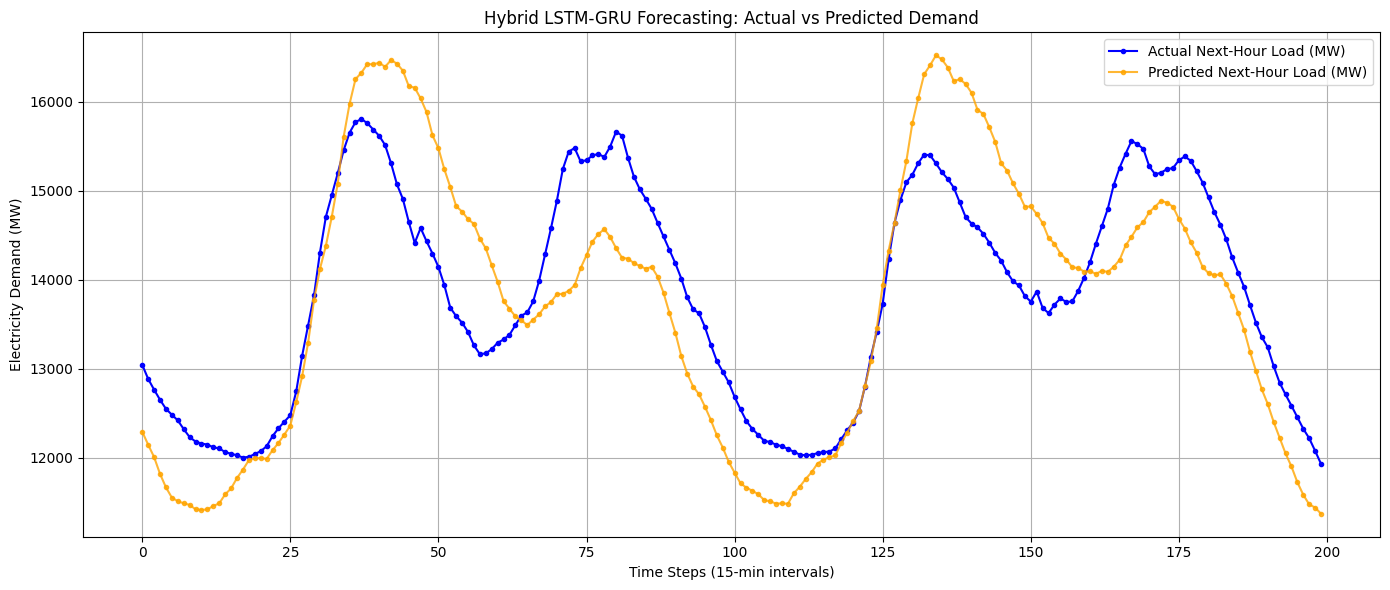

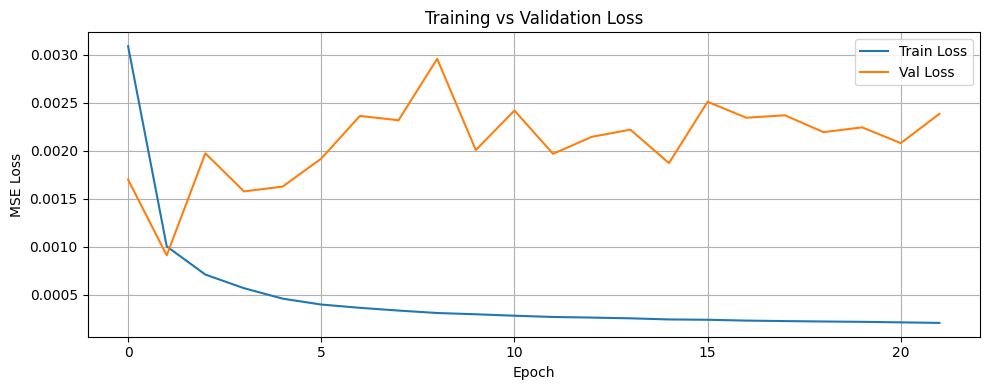

In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

print("1. Loading data...")
# Loading dataset
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/fyp/nl_15min_next_hour_with_weather_model_ready.csv"

df = pd.read_csv(file_path, parse_dates=["timestamp_utc"])
df = df.sort_values("timestamp_utc").reset_index(drop=True)
print(df.head())
print(df.shape)

print("2. Preprocessing & Scaling...")
features = [col for col in df.columns if col not in ['timestamp_utc', 'target_load_plus_60m']]
target = 'target_load_plus_60m'

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[[target]])


joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

print("Scalers saved successfully.")
print("3. Generating Time-Series Sequences...")
# past4 hours (16 timesteps of 15-minutes) to predict the next hour
lookback = 16

X, y = [], []
for i in range(len(scaled_features) - lookback):
    X.append(scaled_features[i:i+lookback])
    y.append(scaled_target[i+lookback])

X = np.array(X)
y = np.array(y)


train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training shape: {X_train.shape} (Samples, Timesteps, Features)")
print(f"Testing shape: {X_test.shape}")

print("4. Building Hybrid GRU-LSTM Model...")
model = Sequential([
    # Layer 1: GRU for fast, initial feature extraction
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Dropout prevents overfitting

    # Layer 2: LSTM for capturing deeper, long-term seasonal dependencies
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Output Layer: Predicting a single continuous value (MW)
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

print("5. Training Model...")
# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

print("6. Evaluating Model...")

y_pred_scaled = model.predict(X_test)

# transform back to real Megawatts (MW)
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

# Calculate standard metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

# Prevent division by zero for MAPE
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

print(f"--- FINAL RESULTS ---")
print(f"Test RMSE: {rmse:.2f} MW")
print(f"Test MAE:  {mae:.2f} MW")
print(f"Test MAPE: {mape:.2f}%")

print("7. Plotting Results...")
plt.figure(figsize=(14, 6))
# Plotting
plt.plot(y_true[-200:], label='Actual Next-Hour Load (MW)', marker='.', color='blue')
plt.plot(y_pred[-200:], label='Predicted Next-Hour Load (MW)', marker='.', color='orange', alpha=0.8)
plt.title('Hybrid LSTM-GRU Forecasting: Actual vs Predicted Demand')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Electricity Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('final_forecast_plot.png')
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curve.png')
plt.show()


model.save('hybrid_load_forecaster.h5')